In [6]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "opencv-python", "numpy", "matplotlib"], check=True)

CompletedProcess(args=['c:\\Users\\alexa\\OneDrive - Stanford\\CS 131\\CS 131 Final Project\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'opencv-python', 'numpy', 'matplotlib'], returncode=0)

# Lens Distortion Correction Demo

This notebook demonstrates that the fisheye lens distortion has been successfully corrected. It shows:

1. A raw video frame with visible barrel distortion
2. The same frame after undistortion
3. A side-by-side comparison with a line overlaid on the field boundary to confirm straightness

In [ ]:
import sys
sys.path.insert(0, "../src")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from lens_distortion import load_params, undistort_image

params = load_params("../data/distortion_params.json")

# Use frame 180 mid-game, matches the reference used during calibration
cap = cv2.VideoCapture("../film.mp4")
cap.set(cv2.CAP_PROP_POS_FRAMES, 180)
ret, raw_bgr = cap.read()
cap.release()

raw = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
undistorted = cv2.cvtColor(undistort_image(raw_bgr, params), cv2.COLOR_BGR2RGB)

print(f"Model : {params.get('model')}")
print(f"fx    : {params['fx']}  (input fisheye focal length, px)")
print(f"k1    : {params['k1']}  (primary distortion coefficient)")
print(f"out_fx: {params.get('out_fx')}  (output focal length controls FOV)")
print(f"Frame : {raw.shape[1]}—{raw.shape[0]} px")

Model : fisheye
fx    : 577.73  (input fisheye focal length, px)
k1    : 0.09  (primary distortion coefficient)
out_fx: 385.16  (output focal length â€” controls FOV)
Frame : 1920Ã—1080 px


## Raw vs. Undistorted

The field boundary line at the bottom curves visibly in the raw frame. After undistortion it is straight.

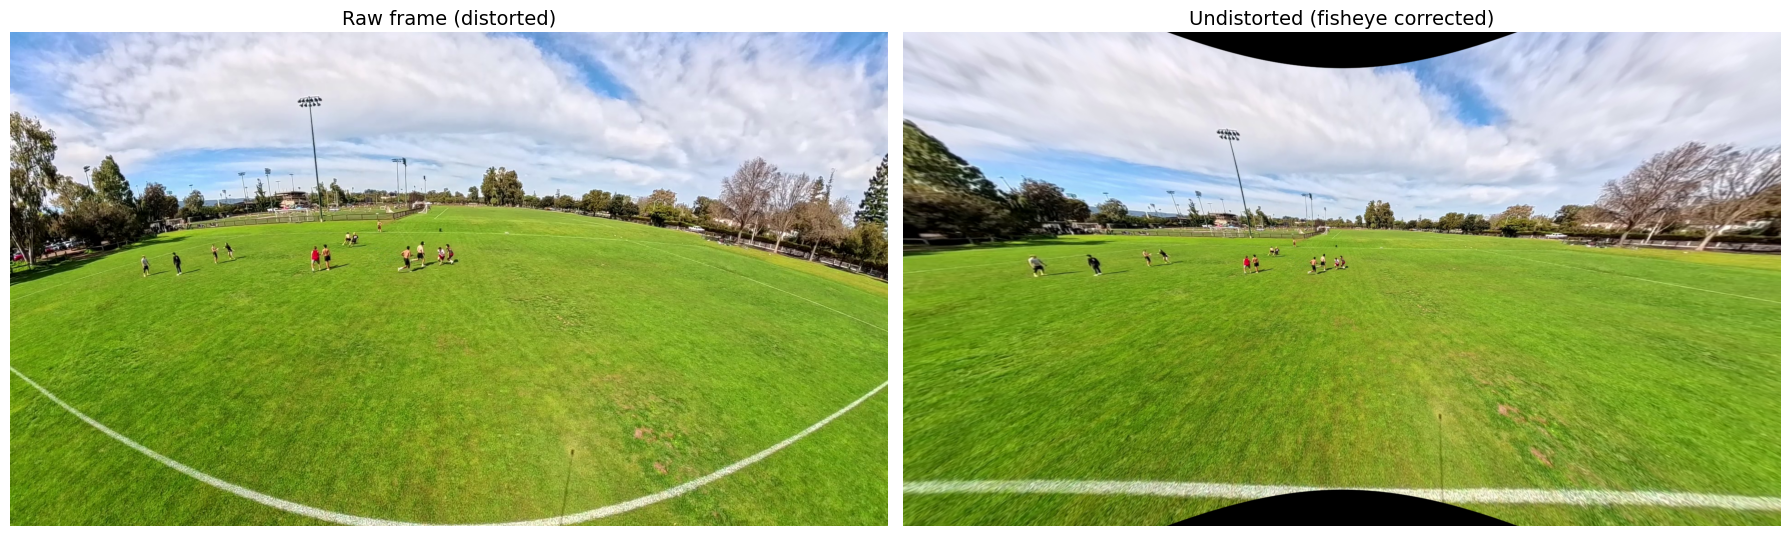

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(raw)
axes[0].set_title("Raw frame (distorted)", fontsize=14)
axes[0].axis("off")

axes[1].imshow(undistorted)
axes[1].set_title("Undistorted (fisheye corrected)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Straightness Check Field Boundary Line

We fit a straight line to the white field boundary pixels in the undistorted image and overlay it. If the correction is good, the fitted line should lie exactly on top of the boundary.

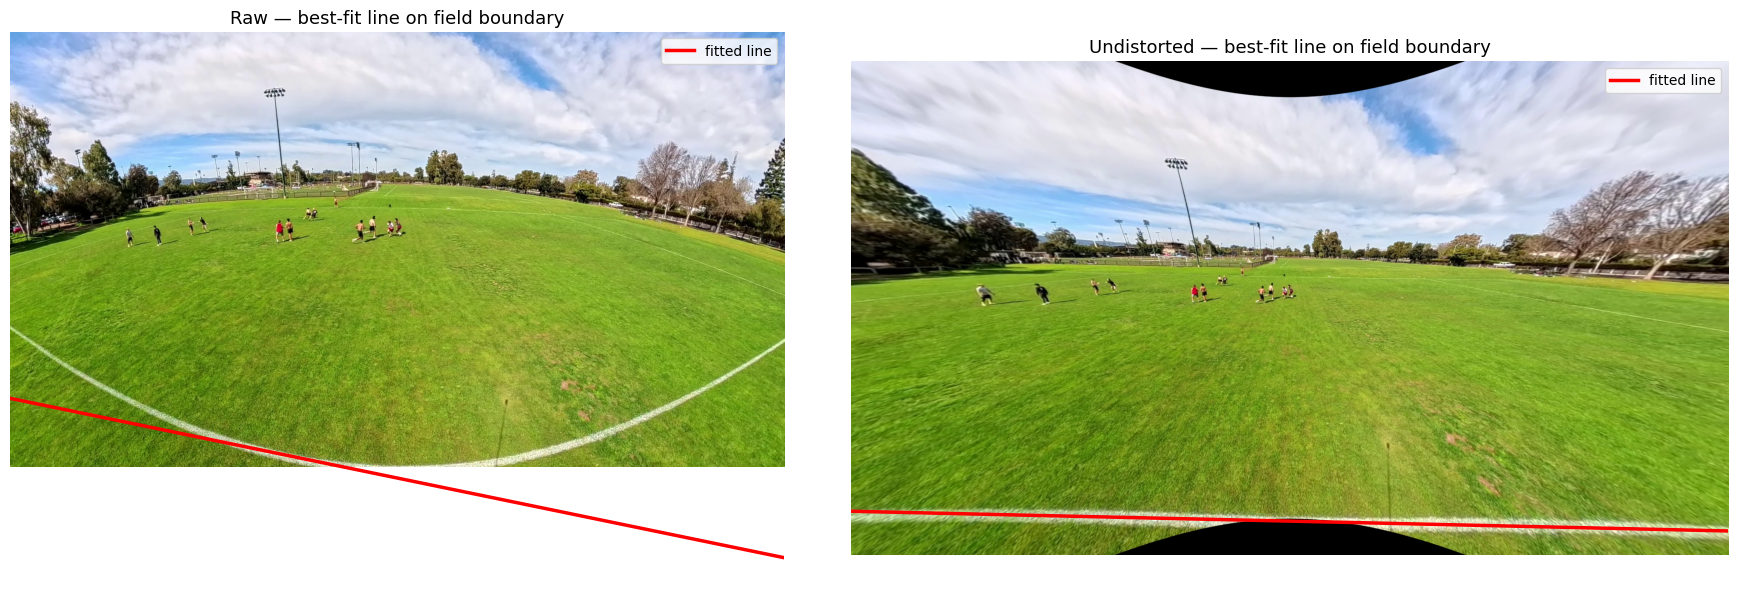

In [20]:
def detect_field_line(image_bgr):
    """
    Detect the white field boundary line in the bottom half of the image.
    Returns (xs, ys) of white pixels and the best-fit line coefficients (a, b)
    for y = a*x + b.
    """
    h, w = image_bgr.shape[:2]
    roi = image_bgr[h // 2:, :]          # look only in the bottom half

    # Threshold for white pixels (high brightness, low saturation)
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, (0, 0, 180), (180, 50, 255))

    # Keep only the largest connected component to exclude noise
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if n_labels < 2:
        return None, None, None
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    clean = (labels == largest).astype(np.uint8) * 255

    ys, xs = np.where(clean > 0)
    ys = ys + h // 2   # shift back to full-image coordinates

    # Fit a line: y = a*x + b
    if len(xs) < 10:
        return None, None, None
    coeffs = np.polyfit(xs, ys, 1)
    return xs, ys, coeffs


undist_bgr = undistort_image(raw_bgr, params)
raw_disp   = cv2.cvtColor(raw_bgr,   cv2.COLOR_BGR2RGB)
undist_disp = cv2.cvtColor(undist_bgr, cv2.COLOR_BGR2RGB)

xs_raw,   ys_raw,   c_raw   = detect_field_line(raw_bgr)
xs_undist, ys_undist, c_undist = detect_field_line(undist_bgr)

h, w = raw_bgr.shape[:2]
x_span = np.array([0, w - 1])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(raw_disp)
if c_raw is not None:
    axes[0].plot(x_span, np.polyval(c_raw, x_span), "r-", linewidth=2.5, label="fitted line")
axes[0].set_title("Raw â€” best-fit line on field boundary", fontsize=13)
axes[0].legend(loc="upper right")
axes[0].axis("off")

axes[1].imshow(undist_disp)
if c_undist is not None:
    axes[1].plot(x_span, np.polyval(c_undist, x_span), "r-", linewidth=2.5, label="fitted line")
axes[1].set_title("Undistorted â€” best-fit line on field boundary", fontsize=13)
axes[1].legend(loc="upper right")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Field Geometry Annotation

This section finds the pixel locations of all four field corners â€” including the two
near corners that are off-frame â€” so they can be passed to `homography.py`.

Field coordinate system:
- **x**: 0â€“70 yards (left endline â†’ right endline)
- **y**: 0â€“40 yards (near sideline â†’ far sideline) â€” **(0, 0) is the bottom-left corner**

The two **far corners** `(0, 40)` and `(70, 40)` are visible in the image and annotated directly.
The two **near corners** `(0, 0)` and `(70, 0)` are off-frame and computed by intersecting:
- the left endline (line through the `(0, 40)` corner + one more visible endline point)
- the right endline (line through the `(70, 40)` corner + one more visible endline point)
- the near sideline (line through two visible points on the near sideline)

### Workflow
1. Run the interactive display cell and hover to find pixel coordinates.
2. Fill in the six pixel locations in the annotation cell.
3. Run the intersection cell â€” it will print the near corner pixel locations
   and draw all four corners overlaid on the frame for visual verification.

In [ ]:
# Opens an interactive window hover anywhere to see live pixel coordinates
# in the bottom-right of the window (shown as x=... y=...).
# Close the window when done, then fill in the annotation cell below.
%matplotlib tk

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(undistorted)
ax.set_title("Hover to read pixel coordinates shown as  x=...  y=...  in the toolbar", fontsize=12)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
plt.tight_layout()
plt.show()

%matplotlib inline  # restore inline rendering for subsequent cells

UsageError: unrecognized arguments: # restore inline rendering for subsequent cells


In [ ]:
# -------------------------------------------------------------------
# Pixel coordinates of six annotated points (from the undistorted frame).
# Use the interactive display cell above to find each (x, y) pixel location.
# -------------------------------------------------------------------

# Far corners â€” visible in the image
far_left_px  = (603, 464)   # field corner (x=0,  y=40)
far_right_px = (1253, 477)   # field corner (x=70, y=40)

# One additional point on each endline (anywhere else visible on that line)
left_endline_extra_px  = (2, 527)   # another point on the x=0  endline
right_endline_extra_px = (1915, 591)   # another point on the x=70 endline

# Two points on the near sideline (y=0 line)
near_sideline_px1 = (1, 995)
near_sideline_px2 = (1918, 1033)

print('Points set â€” run the next cell to compute near corners.')

In [61]:
import numpy as np

def _h(p):
    """Pixel point to homogeneous coordinates."""
    return np.array([p[0], p[1], 1.0])

def line_through(p1, p2):
    """Homogeneous line through two pixel points."""
    return np.cross(_h(p1), _h(p2))

def intersect(l1, l2):
    """Pixel (x, y) intersection of two homogeneous lines."""
    pt = np.cross(l1, l2)
    return pt[:2] / pt[2]

left_endline  = line_through(far_left_px,  left_endline_extra_px)
right_endline = line_through(far_right_px, right_endline_extra_px)
near_sideline = line_through(near_sideline_px1, near_sideline_px2)

near_left_px  = intersect(left_endline,  near_sideline)
near_right_px = intersect(right_endline, near_sideline)

print('Near-left  corner  (x=0,  y=0):', tuple(near_left_px.round(1)))
print('Near-right corner  (x=70, y=0):', tuple(near_right_px.round(1)))

# Visual verification
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(undistorted)

corners = {
    'far_left  (0,40)':  (np.array(far_left_px),  'lime'),
    'far_right (70,40)': (np.array(far_right_px), 'cyan'),
    'near_left (0,0)':   (near_left_px,            'orange'),
    'near_right(70,0)':  (near_right_px,           'red'),
}
for label, (px, color) in corners.items():
    ax.plot(*px, 'o', color=color, markersize=10, label=label)
    ax.annotate(label, px, textcoords='offset points', xytext=(6, 6),
                fontsize=9, color=color,
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

order = ['far_left  (0,40)', 'far_right (70,40)', 'near_right(70,0)', 'near_left (0,0)', 'far_left  (0,40)']
pts = [corners[k][0] for k in order]
ax.plot([p[0] for p in pts], [p[1] for p in pts], 'w--', linewidth=1.5, alpha=0.8)

# Mark the extra line-fitting points
extras = [left_endline_extra_px, right_endline_extra_px, near_sideline_px1, near_sideline_px2]
ax.scatter([p[0] for p in extras], [p[1] for p in extras],
           marker='+', s=140, color='yellow', linewidths=2, zorder=5, label='line-fitting pts')

ax.set_title('Field corners: solid = annotated, dashed = extrapolated off-frame', fontsize=12)
ax.legend(loc='upper right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()

Near-left  corner  (x=0,  y=0): (np.float64(-3752.7), np.float64(920.6))
Near-right corner  (x=70, y=0): (np.float64(4815.2), np.float64(1090.4))


---

## Player Detection

Uses `detect_players.py` (YOLO, person class only) to find active players in the **undistorted** frame.

Design choice: we prefer **false negatives over false positives** â€” it is better to miss a player for a frame or two (and interpolate later) than to hallucinate phantom players.  
Key levers:
- `conf` â€” raise to drop borderline detections; default is `0.3` (vs `0.05` in a raw YOLO run)
- `max_players` â€” hard ceiling of 12; never pads with low-confidence detections to reach that number

In [85]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "ultralytics"], check=True)

KeyboardInterrupt: 

In [91]:
from detect_players import detect_players, draw_detections

# Reuse the undistorted frame already loaded above
feet, detections = detect_players(
    undist_bgr,
    model_path="yolo11n.pt",
    max_players=13,   # +1 to keep 12 players even when the far-sideline spectator uses a slot
    conf=0.2,
    iou=0.7,
    imgsz=1920,
)


  Raw detections: 13, kept (conf≥0.2, cap=13): 13


In [92]:
annotated_bgr = draw_detections(undist_bgr, detections)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(annotated_rgb)
ax.set_title(
    f"Player detection {len(detections)} player(s) found  "
    f"(conf=0.30, max_players=13, imgsz=1920)",
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.show()

print("\nFoot coordinates (x_pixel, y_pixel):")
for i, det in enumerate(detections):
    print(f"  p{i+1:02d}  feet={det['feet']}  conf={det['conf']:.3f}")



Foot coordinates (x_pixel, y_pixel):
  p01  feet=(533, 512)  conf=0.834
  p02  feet=(417, 530)  conf=0.739
  p03  feet=(771, 527)  conf=0.730
  p04  feet=(752, 528)  conf=0.723
  p05  feet=(895, 529)  conf=0.692
  p06  feet=(293, 535)  conf=0.643
  p07  feet=(571, 504)  conf=0.604
  p08  feet=(918, 523)  conf=0.599
  p09  feet=(948, 518)  conf=0.558
  p10  feet=(856, 470)  conf=0.546
  p11  feet=(961, 516)  conf=0.353
  p12  feet=(816, 488)  conf=0.277
  p13  feet=(805, 491)  conf=0.251


---

## Detection Across the Clip

Sample 8 evenly-spaced frames from `data/frames/` (79 frames total) and run player detection on each to check consistency across the 10-second interval.

In [93]:
import glob as _glob

frames_dir = "../data/frames"
all_frames = sorted(_glob.glob(f"{frames_dir}/frame_*.jpg"))
print(f"Total frames available: {len(all_frames)}")

# Pick 8 evenly-spaced indices across the full range
n_samples = 8
indices = [round(i * (len(all_frames) - 1) / (n_samples - 1)) for i in range(n_samples)]
sampled_paths = [all_frames[i] for i in indices]

print("Sampled frame indices:", indices)
print("Paths:", [p.split("/")[-1] for p in sampled_paths])

Total frames available: 78
Sampled frame indices: [0, 11, 22, 33, 44, 55, 66, 77]
Paths: ['frames\\frame_00000.jpg', 'frames\\frame_00011.jpg', 'frames\\frame_00022.jpg', 'frames\\frame_00033.jpg', 'frames\\frame_00044.jpg', 'frames\\frame_00055.jpg', 'frames\\frame_00066.jpg', 'frames\\frame_00077.jpg']


In [111]:
CONF = 0.25
MAX_PLAYERS = 13  # +1 for far-sideline spectator slot
IMGSZ = 1920

results_per_frame = []
for path in sampled_paths:
    bgr = cv2.imread(path)
    feet, dets = detect_players(
        bgr, model_path="yolo11n.pt",
        max_players=MAX_PLAYERS, conf=CONF, iou=0.5, imgsz=IMGSZ,
    )
    results_per_frame.append((path, bgr, dets))


  Raw detections: 9, kept (conf≥0.25, cap=13): 9
  Raw detections: 11, kept (conf≥0.25, cap=13): 11
  Raw detections: 11, kept (conf≥0.25, cap=13): 11
  Raw detections: 13, kept (conf≥0.25, cap=13): 13
  Raw detections: 10, kept (conf≥0.25, cap=13): 10
  Raw detections: 12, kept (conf≥0.25, cap=13): 12
  Raw detections: 12, kept (conf≥0.25, cap=13): 12
  Raw detections: 11, kept (conf≥0.25, cap=13): 11


In [112]:
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
axes = axes.flatten()

for ax, (fpath, bgr, dets) in zip(axes, results_per_frame):
    ann = cv2.cvtColor(draw_detections(bgr, dets), cv2.COLOR_BGR2RGB)
    frame_name = fpath.split("/")[-1].replace(".jpg", "")
    ax.imshow(ann)
    ax.set_title(f"{frame_name} {len(dets)} player(s)", fontsize=11)
    ax.axis("off")

plt.suptitle(
    f"Player detection across the clip  (conf={CONF}, max_players={MAX_PLAYERS}, imgsz={IMGSZ})",
    fontsize=14,
)
plt.tight_layout()
plt.show()


In [46]:
# Summary table: frame name, detection count, and individual confidence scores
print(f"{'Frame':<20} {'Players':>7}  Confidence scores")
print("-" * 60)
for path, _, dets in results_per_frame:
    name = path.split("/")[-1]
    confs = "  ".join(f"{d['conf']:.2f}" for d in dets) if dets else "â€”"
    print(f"{name:<20} {len(dets):>7}  {confs}")

Frame                Players  Confidence scores
------------------------------------------------------------
frames\frame_00000.jpg       9  0.81  0.75  0.73  0.58  0.57  0.55  0.51  0.46  0.44
frames\frame_00011.jpg       8  0.76  0.69  0.66  0.59  0.57  0.49  0.43  0.43
frames\frame_00022.jpg       9  0.77  0.64  0.64  0.63  0.59  0.57  0.56  0.56  0.44
frames\frame_00033.jpg      11  0.71  0.69  0.67  0.66  0.62  0.54  0.51  0.51  0.49  0.49  0.47
frames\frame_00044.jpg       9  0.72  0.64  0.60  0.60  0.59  0.50  0.46  0.43  0.43
frames\frame_00055.jpg      12  0.84  0.76  0.73  0.69  0.66  0.65  0.63  0.56  0.56  0.55  0.47  0.43
frames\frame_00066.jpg      10  0.77  0.74  0.73  0.71  0.69  0.64  0.59  0.53  0.48  0.43
frames\frame_00077.jpg      11  0.89  0.87  0.86  0.81  0.78  0.76  0.55  0.53  0.53  0.51  0.44


---

## Homography Projection

Uses `homography.py` to map each detected player's foot pixel to field coordinates (yards).

**Validation approach**
1. Project the four annotated corner pixels they should land at exactly `(0,40)`, `(70,40)`, `(0,0)`, `(70,0)`.
2. Project detected player feet from the reference frame onto a top-down field diagram.
3. Project feet from all 8 sampled frames and overlay every detection on the same field positions should cluster in the playing area with no implausible outliers.

In [96]:
import sys
import importlib
sys.path.insert(0, "../src")

# Force re-execution of homography.py from disk on every cell run.
import homography as _hom_mod
importlib.reload(_hom_mod)

import numpy as np
import matplotlib.pyplot as plt
from homography import (
    H, project_point, project_points, project_detections,
    draw_top_down_field, plot_players_on_field,
    FIELD_LENGTH_YD, FIELD_WIDTH_YD, _CORNER_PAIRS,
)

# ------------------------------------------------------------------
# 1. Corner round-trip accuracy
# ------------------------------------------------------------------
print("Corner round-trip (should be near exact field coords):")
print(f"  {'Pixel':>25}  {'Expected (yd)':>14}  {'Projected (yd)':>16}  {'Error (yd)':>10}")
for (px, py), (ex, ey) in _CORNER_PAIRS:
    proj = project_point((px, py))
    err  = np.linalg.norm(proj - np.array([ex, ey]))
    print(f"  pixel ({px:7.0f}, {py:5.0f})  ->  ({ex:4.0f}, {ey:4.0f})  ->  "
          f"({proj[0]:6.2f}, {proj[1]:6.2f})  err={err:.4f} yd")

# ------------------------------------------------------------------
# 2. Single reference frame - project the detections already computed above
# ------------------------------------------------------------------
# ── Exclusion zone: suppress the far-sideline spectator ──────────────
SPECTATOR_PX = [
    # (pixel_x, pixel_y, radius_yd) — same values as tracking_debug.ipynb
    (855, 466, 8),
]
exclusion_zones = []
for px, py, r in SPECTATOR_PX:
    x_yd, y_yd = project_point((px, py))
    exclusion_zones.append((float(x_yd), float(y_yd), r))
    print(f"  Exclusion zone: pixel ({px},{py}) -> field ({x_yd:.1f}, {y_yd:.1f}) yd, r={r} yd")

projected_ref = project_detections(detections, margin=5.0, exclusion_zones=exclusion_zones)
print(f"\nReference frame: {len(detections)} detected, "
      f"{len(projected_ref)} projected on-field")

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].imshow(cv2.cvtColor(draw_detections(undist_bgr, detections), cv2.COLOR_BGR2RGB))
axes[0].set_title("Undistorted frame - detected players", fontsize=13)
axes[0].axis("off")

draw_top_down_field(axes[1], title="Projected player positions - reference frame")
plot_players_on_field(axes[1], projected_ref, color="yellow", label="player")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

Corner round-trip (should be near exact field coords):
                      Pixel   Expected (yd)    Projected (yd)  Error (yd)
  pixel (    603,   464)  ->  (   0,   40)  ->  (  0.00,  40.00)  err=0.0000 yd
  pixel (   1253,   477)  ->  (  70,   40)  ->  ( 70.00,  40.00)  err=0.0000 yd
  pixel (  -3753,   921)  ->  (   0,    0)  ->  (  0.00,   0.00)  err=0.0000 yd
  pixel (   4815,  1090)  ->  (  70,    0)  ->  ( 70.00,   0.00)  err=0.0000 yd
  Exclusion zone: pixel (855,466) -> field (26.3, 43.2) yd, r=8 yd

Reference frame: 13 detected, 12 projected on-field
